In [5]:
import wrds
import pandas as pd
import numpy as np
import re
from pathlib import Path

Path("data").mkdir(exist_ok=True)
Path("data/raw").mkdir(exist_ok=True)
Path("data/processed").mkdir(exist_ok=True)

In [12]:
conn = wrds.Connection(wrds_username="sihan321")

Loading library list...
Done


In [4]:
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))

sp500 = tables[0]

sp500 = sp500.rename(columns={
    "Symbol": "ticker",
    "Security": "security",
    "GICS Sector": "sector",
    "GICS Sub-Industry": "sub_industry"
})

sp500["ticker_clean"] = (
    sp500["ticker"]
    .astype(str)
    .str.upper()
    .str.replace(".", "-", regex=False)
)

sp500[["ticker", "ticker_clean", "security", "sector", "sub_industry"]].head()

,ticker,ticker_clean,security,sector,sub_industry
0,MMM,MMM,3M,Industrials,Industrial Conglomerates
1,AOS,AOS,A. O. Smith,Industrials,Building Products
2,ABT,ABT,Abbott Laboratories,Health Care,Health Care Equipment
3,ABBV,ABBV,AbbVie,Health Care,Biotechnology
4,ACN,ACN,Accenture,Information Technology,IT Consulting & Other Services


In [5]:
clean_calls_with_ticker = conn.raw_sql("""
WITH filtered AS (
    SELECT
        companyid,
        companyname,
        keydevid,
        transcriptid,
        headline,
        mostimportantdateutc,
        keydeveventtypename,
        transcriptcollectiontypename,
        transcriptpresentationtypename,
        transcriptcreationdate_utc
    FROM ciq_transcripts.wrds_transcript_detail
    WHERE keydeveventtypename = 'Earnings Calls'
      AND transcriptpresentationtypename = 'Final'
      AND mostimportantdateutc BETWEEN '2021-01-01' AND '2025-12-31'
      AND LOWER(headline) LIKE '%%earnings call%%'
      AND LOWER(headline) NOT LIKE '%%pre recorded%%'
      AND LOWER(headline) NOT LIKE '%%pre-recorded%%'
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY companyid, mostimportantdateutc
            ORDER BY
                CASE
                    WHEN transcriptcollectiontypename = 'Audited Copy' THEN 1
                    WHEN transcriptcollectiontypename = 'Proofed Copy' THEN 2
                    WHEN transcriptcollectiontypename = 'Edited Copy' THEN 3
                    WHEN transcriptcollectiontypename = 'EV Copy' THEN 4
                    ELSE 5
                END,
                transcriptcreationdate_utc DESC,
                transcriptid DESC
        ) AS rn
    FROM filtered
),
clean_calls AS (
    SELECT *
    FROM ranked
    WHERE rn = 1
),
ticker_matched AS (
    SELECT
        c.companyid,
        c.companyname,
        c.keydevid,
        c.transcriptid,
        c.headline,
        c.mostimportantdateutc AS call_date,
        c.transcriptcollectiontypename,
        t.ticker,
        t.startdate AS ticker_startdate,
        t.enddate AS ticker_enddate,
        t.primaryflag
    FROM clean_calls AS c
    LEFT JOIN ciq_common.wrds_ticker AS t
        ON c.companyid = t.companyid
       AND t.primaryflag = 1
       AND t.startdate <= c.mostimportantdateutc
       AND (t.enddate IS NULL OR t.enddate >= c.mostimportantdateutc)
)
SELECT *
FROM ticker_matched
WHERE ticker IS NOT NULL
ORDER BY companyname, call_date
""")

print(clean_calls_with_ticker.shape)
clean_calls_with_ticker.head()

(148172, 11)


,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag
0,160130.0,01 Quantum Inc.,701176338.0,2249638.0,"01 Communique Laboratory Inc., Q4 2020 Earning...",2021-01-14,Audited Copy,ONE,2002-07-13,<NA>,1
1,160130.0,01 Quantum Inc.,717879688.0,2316497.0,"01 Communique Laboratory Inc., Q2 2021 Earning...",2021-06-10,Edited Copy,ONE,2002-07-13,<NA>,1
2,160130.0,01 Quantum Inc.,1680452476.0,2405134.0,"01 Communique Laboratory Inc., Q3 2021 Earning...",2021-09-09,Proofed Copy,ONE,2002-07-13,<NA>,1
3,160130.0,01 Quantum Inc.,1763820791.0,2485819.0,"01 Communique Laboratory Inc., 2021 Earnings C...",2022-01-13,Audited Copy,ONE,2002-07-13,<NA>,1
4,160130.0,01 Quantum Inc.,1774364602.0,2533379.0,"01 Communique Laboratory Inc., Q1 2022 Earning...",2022-03-17,Audited Copy,ONE,2002-07-13,<NA>,1


In [6]:
clean_calls_with_ticker.to_csv(
    "data/raw/clean_earnings_call_metadata_2021_2025.csv",
    index=False
)

In [7]:
clean_calls_with_ticker["ticker"] = clean_calls_with_ticker["ticker"].astype(str).str.upper()

clean_calls_sp500 = clean_calls_with_ticker.merge(
    sp500[["ticker_clean", "security", "sector", "sub_industry"]],
    left_on="ticker",
    right_on="ticker_clean",
    how="inner"
)

print(clean_calls_sp500.shape)
print(clean_calls_sp500["ticker"].nunique())

clean_calls_sp500.head()

(10766, 15)
493


,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry
0,256329698.0,1&1 AG,704417895.0,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
1,256329698.0,1&1 AG,709546971.0,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
2,256329698.0,1&1 AG,714259265.0,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
3,256329698.0,1&1 AG,1676316704.0,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
4,256329698.0,1&1 AG,1757355285.0,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants


In [8]:
firm_call_count_sp500 = (
    clean_calls_sp500
    .groupby(["companyid", "companyname", "ticker", "security", "sector"])
    .size()
    .reset_index(name="n_calls")
)

firm_sample_sp500_200 = (
    firm_call_count_sp500
    .query("n_calls >= 12")
    .sort_values(["n_calls", "ticker"], ascending=[False, True])
    .head(200)
)

metadata_sample_sp500_200 = clean_calls_sp500[
    clean_calls_sp500["companyid"].isin(firm_sample_sp500_200["companyid"])
].copy()

metadata_sample_sp500_200.to_csv(
    "data/raw/metadata_sample_sp500_200_firms.csv",
    index=False
)

print(metadata_sample_sp500_200.shape)
print(metadata_sample_sp500_200["companyid"].nunique())

metadata_sample_sp500_200.head()

(4021, 15)
200


,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry
0,256329698.0,1&1 AG,704417895.0,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
1,256329698.0,1&1 AG,709546971.0,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
2,256329698.0,1&1 AG,714259265.0,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
3,256329698.0,1&1 AG,1676316704.0,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
4,256329698.0,1&1 AG,1757355285.0,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants


In [9]:
component_desc = conn.describe_table(
    library="ciq_transcripts",
    table="ciqtranscriptcomponent"
)

component_desc[["name", "type"]]

Approximately 91226539 rows in ciq_transcripts.ciqtranscriptcomponent.


,name,type
0,transcriptcomponentid,INTEGER
1,transcriptid,INTEGER
2,componentorder,SMALLINT
3,transcriptcomponenttypeid,SMALLINT
4,transcriptpersonid,INTEGER
5,componenttext,VARCHAR


In [10]:
transcript_ids = (
    metadata_sample_sp500_200["transcriptid"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

len(transcript_ids)

4021

In [16]:
try:
    conn.connection.rollback()
    print("Rollback successful.")
except Exception as e:
    print("Rollback failed:", e)

Rollback successful.


In [17]:
from pathlib import Path

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

Path("data/raw/transcript_batches").mkdir(parents=True, exist_ok=True)

batch_size = 300

for batch_no, ids in enumerate(chunks(transcript_ids, batch_size), start=1):
    ids_str = ",".join(map(str, ids))
    
    components = conn.raw_sql(f"""
    SELECT
        transcriptid,
        transcriptcomponentid,
        componentorder,
        componenttext
    FROM ciq_transcripts.ciqtranscriptcomponent
    WHERE transcriptid IN ({ids_str})
    ORDER BY transcriptid, componentorder
    """)
    
    full_texts = (
        components
        .dropna(subset=["componenttext"])
        .sort_values(["transcriptid", "componentorder"])
        .groupby("transcriptid")["componenttext"]
        .apply(lambda x: "\n".join(x.astype(str)))
        .reset_index()
        .rename(columns={"componenttext": "transcript_text"})
    )
    
    out_path = f"data/raw/transcript_batches/full_text_batch_{batch_no:03d}.csv"
    full_texts.to_csv(out_path, index=False)
    
    print(f"Batch {batch_no}: {full_texts.shape}")

Batch 1: (300, 2)
Batch 2: (300, 2)
Batch 3: (300, 2)
Batch 4: (300, 2)
Batch 5: (300, 2)
Batch 6: (300, 2)
Batch 7: (300, 2)
Batch 8: (300, 2)
Batch 9: (300, 2)
Batch 10: (300, 2)
Batch 11: (300, 2)
Batch 12: (300, 2)
Batch 13: (300, 2)
Batch 14: (121, 2)


In [18]:
files = sorted(Path("data/raw/transcript_batches").glob("full_text_batch_*.csv"))

full_texts = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

dataset_text = metadata_sample_sp500_200.merge(
    full_texts,
    on="transcriptid",
    how="left"
)

dataset_text.to_csv(
    "data/raw/earnings_call_transcripts_sp500_200_with_text.csv",
    index=False
)

print(dataset_text.shape)
print(dataset_text["transcript_text"].notna().mean())
dataset_text.head()

(4021, 16)
1.0


,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry,transcript_text
0,256329698.0,1&1 AG,704417895.0,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,[Interpreted] I'm delighted to welcome you her...
1,256329698.0,1&1 AG,709546971.0,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,"Thank you, operator. Welcome, ladies and gentl..."
2,256329698.0,1&1 AG,714259265.0,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,"Good day, and welcome to the 1&1 Drillisch AG ..."
3,256329698.0,1&1 AG,1676316704.0,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,"Welcome, ladies and gentlemen. We welcome you ..."
4,256329698.0,1&1 AG,1757355285.0,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,"Dear ladies and gentlemen, welcome to the 1&1 ..."


In [19]:
from pathlib import Path

Path("data/processed").mkdir(parents=True, exist_ok=True)

dataset_text.to_csv(
    "data/processed/earnings_call_transcripts_sp500_200_with_text.csv",
    index=False
)

In [20]:
summary = {
    "n_rows": dataset_text.shape[0],
    "n_columns": dataset_text.shape[1],
    "n_companies": dataset_text["companyid"].nunique(),
    "n_tickers": dataset_text["ticker"].nunique(),
    "n_transcripts": dataset_text["transcriptid"].nunique(),
    "text_match_rate": dataset_text["transcript_text"].notna().mean(),
    "start_date": dataset_text["call_date"].min(),
    "end_date": dataset_text["call_date"].max()
}

summary

{'n_rows': 4021,
 'n_columns': 16,
 'n_companies': 200,
 'n_tickers': 189,
 'n_transcripts': 4021,
 'text_match_rate': np.float64(1.0),
 'start_date': '2021-01-07',
 'end_date': '2025-12-19'}

In [21]:
from pathlib import Path
import pandas as pd

Path("data/processed").mkdir(parents=True, exist_ok=True)

pd.DataFrame([summary]).to_csv(
    "data/processed/sample_summary_sp500_200.csv",
    index=False
)

In [25]:
import re
import numpy as np
import pandas as pd
ai_keywords = [
    "ai",
    "artificial intelligence",
    "generative ai",
    "gen ai",
    "genai",
    "machine learning",
    "deep learning",
    "natural language processing",
    "large language model",
    "large language models",
    "llm",
    "llms",
    "foundation model",
    "foundation models",
    "neural network",
    "neural networks",
    "computer vision",
    "predictive ai",
    "ai model",
    "ai models",
    "ai platform",
    "ai platforms",
    "ai assistant",
    "ai assistants",
    "chatbot",
    "chatbots",
    "chatgpt",
    "gpt",
    "gpt-3",
    "gpt-4",
    "openai",
    "copilot",
    "gemini",
    "claude",
    "anthropic"
]

ai_pattern = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in ai_keywords) + r")\b",
    flags=re.IGNORECASE
)

def split_sentences(text):
    if pd.isna(text):
        return []
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", str(text)) if s.strip()]

def compute_ai_vars(text):
    sentences = split_sentences(text)
    total = len(sentences)
    ai_count = sum(1 for s in sentences if ai_pattern.search(s))
    
    return pd.Series({
        "total_sentences": total,
        "ai_sentence_count": ai_count,
        "ai_intensity": ai_count / total if total > 0 else np.nan
    })

ai_vars = dataset_text["transcript_text"].apply(compute_ai_vars)

dataset_processed = pd.concat(
    [dataset_text.drop(columns=["transcript_text"]), ai_vars],
    axis=1
)

In [30]:
from pathlib import Path

Path("data/processed").mkdir(parents=True, exist_ok=True)

dataset_processed.to_csv(
    "data/processed/earnings_call_ai_intensity_sp500_200.csv",
    index=False
)

In [26]:
dataset_processed[
    ["ticker", "call_date", "headline", "total_sentences", "ai_sentence_count", "ai_intensity"]
].head(20)

,ticker,call_date,headline,total_sentences,ai_sentence_count,ai_intensity
0,DRI,2021-02-15,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",527.0,0.0,0.000000
1,DRI,2021-03-25,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",400.0,0.0,0.000000
2,DRI,2021-05-11,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",329.0,0.0,0.000000
3,DRI,2021-08-05,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",515.0,0.0,0.000000
4,DRI,2021-11-09,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",408.0,0.0,0.000000
5,DRI,2022-03-18,"1&1 AG, 2021 Earnings Call, Mar 18, 2022",559.0,0.0,0.000000
6,DRI,2022-05-12,"1&1 AG, Q1 2022 Earnings Call, May 12, 2022",397.0,0.0,0.000000
7,DRI,2022-08-04,"1&1 AG, H1 2022 Earnings Call, Aug 04, 2022",382.0,0.0,0.000000
8,DRI,2022-11-10,"1&1 AG, Q3 2022 Earnings Call, Nov 10, 2022",358.0,0.0,0.000000
9,DRI,2023-03-30,"1&1 AG, 2022 Earnings Call, Mar 30, 2023",500.0,0.0,0.000000


In [27]:
dataset_processed[["total_sentences", "ai_sentence_count", "ai_intensity"]].describe()

,total_sentences,ai_sentence_count,ai_intensity
count,4021.00000,4021.000000,4021.000000
mean,484.54290,3.768217,0.007684
std,111.91686,10.920267,0.022174
min,82.00000,0.000000,0.000000
25%,425.00000,0.000000,0.000000
50%,484.00000,0.000000,0.000000
75%,545.00000,2.000000,0.003344
max,1108.00000,117.000000,0.211957


In [28]:
(dataset_processed["ai_sentence_count"] > 0).mean()

np.float64(0.367072867445909)

In [29]:
def extract_ai_sentences(text):
    sentences = split_sentences(text)
    return " ||| ".join([s for s in sentences if ai_pattern.search(s)])

dataset_processed["ai_sentences"] = dataset_text["transcript_text"].apply(extract_ai_sentences)

dataset_processed.loc[
    dataset_processed["ai_sentence_count"] > 0,
    ["ticker", "call_date", "headline", "ai_sentence_count", "ai_intensity", "ai_sentences"]
].head(20)

,ticker,call_date,headline,ai_sentence_count,ai_intensity,ai_sentences
13,DRI,2024-03-21,"1&1 AG, 2023 Earnings Call, Mar 21, 2024",2.0,0.002829,"Now when I look at what's happening with AI, t..."
19,DRI,2025-08-07,"1&1 AG, Q2 2025 Earnings Call, Aug 07, 2025",1.0,0.002457,"Additionally, we can invest it in AI."
31,ABT,2023-07-20,"Abbott Laboratories, Q2 2023 Earnings Call, Ju...",2.0,0.003839,And if I think about everything that's going o...
40,ABT,2025-10-15,"Abbott Laboratories, Q3 2025 Earnings Call, Oc...",1.0,0.001715,"This quarter, we actually bought an AI-powered..."
43,ABBV,2021-07-30,"AbbVie Inc., Q2 2021 Earnings Call, Jul 30, 2021",1.0,0.001481,"And lastly, in eye care, at the recent meeting..."
58,ABBV,2025-04-25,"AbbVie Inc., Q1 2025 Earnings Call, Apr 25, 2025",1.0,0.001418,The team has applied machine learning to these...
59,ABBV,2025-07-31,"AbbVie Inc., Q2 2025 Earnings Call, Jul 31, 2025",1.0,0.001792,"So again, pretty important in terms of how we ..."
61,ACN,2021-03-18,"Accenture plc, Q2 2021 Earnings Call, Mar 18, ...",6.0,0.013605,COVID has hit a giant fast-forward button to t...
62,ACN,2021-06-24,"Accenture plc, Q3 2021 Earnings Call, Jun 24, ...",3.0,0.007143,SynOps will deliver AI-powered insights and hi...
63,ACN,2021-09-23,"Accenture plc, Q4 2021 Earnings Call, Sep 23, ...",2.0,0.004098,"Just over 1 year ago, we created Accenture Clo..."


In [32]:
dataset_processed["call_date"] = pd.to_datetime(dataset_processed["call_date"])

dataset_processed["hype_period"] = np.select(
    [
        dataset_processed["call_date"] < pd.Timestamp("2022-11-30"),
        (dataset_processed["call_date"] >= pd.Timestamp("2022-11-30")) &
        (dataset_processed["call_date"] <= pd.Timestamp("2023-12-31")),
        dataset_processed["call_date"] >= pd.Timestamp("2024-01-01")
    ],
    [
        "Pre-ChatGPT Baseline",
        "Initial AI Hype Surge",
        "Normalization / Early Adoption"
    ],
    default="Unknown"
)

dataset_processed.to_csv(
    "data/processed/assignment3_processed_ai_discussion_dataset.csv",
    index=False
)

dataset_processed.head()

,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry,total_sentences,ai_sentence_count,ai_intensity,ai_sentences,hype_period
0,256329698.0,1&1 AG,704417895.0,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,527.0,0.0,0.0,,Pre-ChatGPT Baseline
1,256329698.0,1&1 AG,709546971.0,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,400.0,0.0,0.0,,Pre-ChatGPT Baseline
2,256329698.0,1&1 AG,714259265.0,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,329.0,0.0,0.0,,Pre-ChatGPT Baseline
3,256329698.0,1&1 AG,1676316704.0,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,515.0,0.0,0.0,,Pre-ChatGPT Baseline
4,256329698.0,1&1 AG,1757355285.0,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,<NA>,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,408.0,0.0,0.0,,Pre-ChatGPT Baseline


In [33]:
import os

os.path.exists("data/processed/assignment3_processed_ai_discussion_dataset.csv")

True

In [34]:
check_df = pd.read_csv("data/processed/assignment3_processed_ai_discussion_dataset.csv")
check_df.head()

,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry,total_sentences,ai_sentence_count,ai_intensity,ai_sentences,hype_period
0,256329698.0,1&1 AG,7.044179e+08,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,527.0,0.0,0.0,NaN,Pre-ChatGPT Baseline
1,256329698.0,1&1 AG,7.095470e+08,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,400.0,0.0,0.0,NaN,Pre-ChatGPT Baseline
2,256329698.0,1&1 AG,7.142593e+08,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,329.0,0.0,0.0,NaN,Pre-ChatGPT Baseline
3,256329698.0,1&1 AG,1.676317e+09,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,515.0,0.0,0.0,NaN,Pre-ChatGPT Baseline
4,256329698.0,1&1 AG,1.757355e+09,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants,408.0,0.0,0.0,NaN,Pre-ChatGPT Baseline


In [35]:
dataset_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   companyid                     4021 non-null   Float64       
 1   companyname                   4021 non-null   string        
 2   keydevid                      4021 non-null   Float64       
 3   transcriptid                  4021 non-null   Float64       
 4   headline                      4021 non-null   string        
 5   call_date                     4021 non-null   datetime64[ns]
 6   transcriptcollectiontypename  4021 non-null   string        
 7   ticker                        4021 non-null   object        
 8   ticker_startdate              4021 non-null   string        
 9   ticker_enddate                18 non-null     string        
 10  primaryflag                   4021 non-null   Int64         
 11  ticker_clean                  

In [36]:
dataset_processed.isna().sum()

companyid                          0
companyname                        0
keydevid                           0
transcriptid                       0
headline                           0
call_date                          0
transcriptcollectiontypename       0
ticker                             0
ticker_startdate                   0
ticker_enddate                  4003
primaryflag                        0
ticker_clean                       0
security                           0
sector                             0
sub_industry                       0
total_sentences                    0
ai_sentence_count                  0
ai_intensity                       0
ai_sentences                       0
hype_period                        0
dtype: int64

In [37]:
dataset_processed["ai_intensity"].describe()

count    4021.000000
mean        0.007684
std         0.022174
min         0.000000
25%         0.000000
50%         0.000000
75%         0.003344
max         0.211957
Name: ai_intensity, dtype: float64

In [38]:
(dataset_processed["ai_sentence_count"] > 0).value_counts()

ai_sentence_count
False    2545
True     1476
Name: count, dtype: int64

In [39]:
ai_presence_by_period = dataset_processed.groupby("hype_period").agg(
    n_calls=("transcriptid", "count"),
    ai_call_count=("ai_sentence_count", lambda x: (x > 0).sum()),
    ai_call_share=("ai_sentence_count", lambda x: (x > 0).mean()),
    mean_ai_intensity=("ai_intensity", "mean"),
    median_ai_intensity=("ai_intensity", "median")
).reset_index()

ai_presence_by_period

,hype_period,n_calls,ai_call_count,ai_call_share,mean_ai_intensity,median_ai_intensity
0,Initial AI Hype Surge,819,285,0.347985,0.007826,0.000000
1,Normalization / Early Adoption,1606,878,0.546700,0.014355,0.001931
2,Pre-ChatGPT Baseline,1596,313,0.196115,0.000898,0.000000


In [40]:
pd.set_option("display.max_colwidth", 500)

pre_ai_sample = dataset_processed.loc[
    (dataset_processed["hype_period"] == "Pre-ChatGPT Baseline") &
    (dataset_processed["ai_sentence_count"] > 0),
    ["companyname", "call_date", "headline", "ai_sentence_count", "ai_intensity", "ai_sentences"]
].sample(20, random_state=42)

pre_ai_sample

,companyname,call_date,headline,ai_sentence_count,ai_intensity,ai_sentences
661,"Applied Materials, Inc.",2021-02-18,"Applied Materials, Inc., Q1 2021 Earnings Call, Feb 18, 2021",1.0,0.001949,"We'll officially introduce the new system in the near future to explain its unique architectural features, along with breakthrough AI capabilities that are generating strong customer pull."
83,Adobe Inc.,2021-09-21,"Adobe Inc., Q3 2021 Earnings Call, Sep 21, 2021",5.0,0.011416,"Q3 Creative Cloud highlights include innovative enhancements to our photography offerings, including new services and AI-driven capabilities in Lightroom; Creative Cloud applications now running natively on Apple's new silicon M1 chip, delivering a boost in performance; the release of Adobe Substance 3D Collection, a suite of interoperable tools and services that support 3D creativity; partnerships such as The Great Untold with Netflix, enabling next-gen creators to tell their stories; and k..."
2784,eBay Inc.,2021-04-28,"eBay Inc., Q1 2021 Earnings Call, Apr 28, 2021",2.0,0.004049,"Growth was driven by increased seller adoption and AI improvements that increased conversion. ||| And a lot of the marketing technology that we've built and we worked on, the AI with recommendations, et cetera, is really centered on this idea of capturing buyers and having them transact in multiple categories."
1646,"Charles River Laboratories International, Inc.",2022-02-16,"Charles River Laboratories International, Inc., Q4 2021 Earnings Call, Feb 16, 2022",6.0,0.009346,"We recently signed a new partnership with Valo Health to deliver a new type of offering that combines Valo's artificial intelligence, or AI-enabled drug discovery and development platform, with our own capabilities to expedite the discovery of small molecule therapies for clients. ||| You called out Valo, the partnership there in the AI/ML space. ||| I'm just wondering if you can provide any updates around any case studies using AI and ML in different ways that actually can impact what you'r..."
767,"Arista Networks, Inc.",2022-08-01,"Arista Networks, Inc., Q2 2022 Earnings Call, Aug 01, 2022",1.0,0.001799,"AI and ML also see [indiscernible] are doing well, too."
322,"Amazon.com, Inc.",2021-04-29,"Amazon.com, Inc., Q1 2021 Earnings Call, Apr 29, 2021",2.0,0.006993,"We're using new deep learning models to show more relevant sponsored products. ||| As we talked about before, advances in AI and machine learning, and really deliver tools that help developers and the makers of those devices build for and with Alexa, because in that community, it's not just our Echo devices, but also a variety of third-party device manufacturers."
3759,"Salesforce, Inc.",2021-02-25,"salesforce.com, inc., Q4 2021 Earnings Call, Feb 25, 2021",7.0,0.016471,"Now Salesforce Einstein, which is our core artificial intelligence capability, really built in the heart of Customer 360. ||| Well, that's now delivering more than 93 billion, 93 billion AI-powered predictions every single day, 93 billion AI-powered predictions every single day across our entire Customer 360, amazing. ||| My question is where are you in the demand cycle for Einstein and the AI technologies? ||| But it seems like right now is the moment that most companies are finally really ..."
2349,DaVita Inc.,2022-08-01,"DaVita Inc., Q2 2022 Earnings Call, Aug 01, 2022",1.0,0.002532,"If you look at ESA, which has been historically our most expensive pharmaceutical, we have personalized dosing and AI algorithms of the type that you described."
3722,Quest Diagnostics Incorporated,2022-10-20,"Quest Diagnostics Incorporated, Q3 2022 Earnings Call, Oct 20, 2022",1.0,0.001957,"Finally, we continue to drive the use of automation and artificial intelligence to drive productivity gains to help offset inflationary pressures."
3564,General Electric Company,2021-01-26,"General Electric Company, Q4 2020 Earnings Call, Jan 26, 2021",1.0,0.001786,"For example, our Renewables and digital teams are wor

## Add 2019 Pre-Pandemic Baseline Data

In [1]:
from pathlib import Path

list(Path("data/raw").glob("*.csv"))

[PosixPath('data/raw/clean_earnings_call_metadata_2021_2025.csv'),
 PosixPath('data/raw/earnings_call_transcripts_sp500_200_with_text.csv'),
 PosixPath('data/raw/metadata_sample_sp500_200_firms.csv')]

In [2]:
import pandas as pd
import numpy as np

dataset_text_old = pd.read_csv(
    "data/raw/earnings_call_transcripts_sp500_200_with_text.csv"
)

dataset_text_old.shape

(4021, 16)

In [3]:
dataset_text_old["call_date"] = pd.to_datetime(dataset_text_old["call_date"])

dataset_text_old["call_date"].min(), dataset_text_old["call_date"].max()

(Timestamp('2021-01-07 00:00:00'), Timestamp('2025-12-19 00:00:00'))

## Pull 2019 Metadata

In [7]:
conn

In [10]:
metadata_sample = pd.read_csv(
    "data/raw/metadata_sample_sp500_200_firms.csv"
)

metadata_sample.shape
metadata_sample.columns
metadata_sample.head()

,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag,ticker_clean,security,sector,sub_industry
0,256329698.0,1&1 AG,7.044179e+08,2212548.0,"1&1 Drillisch AG, Q4 2020 Earnings Call, Feb 1...",2021-02-15,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
1,256329698.0,1&1 AG,7.095470e+08,2244374.0,"1&1 Drillisch AG, 2020 Earnings Call, Mar 25, ...",2021-03-25,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
2,256329698.0,1&1 AG,7.142593e+08,2279529.0,"1&1 Drillisch AG, Q1 2021 Earnings Call, May 1...",2021-05-11,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
3,256329698.0,1&1 AG,1.676317e+09,2366516.0,"1&1 AG, H1 2021 Earnings Call, Aug 05, 2021",2021-08-05,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants
4,256329698.0,1&1 AG,1.757355e+09,2432056.0,"1&1 AG, Q3 2021 Earnings Call, Nov 09, 2021",2021-11-09,Edited Copy,DRI,2017-09-09,NaN,1,DRI,Darden Restaurants,Consumer Discretionary,Restaurants


In [13]:
import wrds

conn = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [14]:
clean_calls_2019 = conn.raw_sql("""
WITH filtered AS (
    SELECT
        companyid,
        companyname,
        keydevid,
        transcriptid,
        headline,
        mostimportantdateutc,
        keydeveventtypename,
        transcriptcollectiontypename,
        transcriptpresentationtypename,
        transcriptcreationdate_utc
    FROM ciq_transcripts.wrds_transcript_detail
    WHERE keydeveventtypename = 'Earnings Calls'
      AND transcriptpresentationtypename = 'Final'
      AND mostimportantdateutc BETWEEN '2019-01-01' AND '2019-12-31'
      AND LOWER(headline) LIKE '%%earnings call%%'
      AND LOWER(headline) NOT LIKE '%%pre recorded%%'
      AND LOWER(headline) NOT LIKE '%%pre-recorded%%'
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY companyid, mostimportantdateutc
            ORDER BY
                CASE
                    WHEN transcriptcollectiontypename = 'Audited Copy' THEN 1
                    WHEN transcriptcollectiontypename = 'Proofed Copy' THEN 2
                    WHEN transcriptcollectiontypename = 'Edited Copy' THEN 3
                    WHEN transcriptcollectiontypename = 'EV Copy' THEN 4
                    ELSE 5
                END,
                transcriptcreationdate_utc DESC,
                transcriptid DESC
        ) AS rn
    FROM filtered
),
clean_calls AS (
    SELECT *
    FROM ranked
    WHERE rn = 1
),
ticker_matched AS (
    SELECT
        c.companyid,
        c.companyname,
        c.keydevid,
        c.transcriptid,
        c.headline,
        c.mostimportantdateutc AS call_date,
        c.transcriptcollectiontypename,
        t.ticker,
        t.startdate AS ticker_startdate,
        t.enddate AS ticker_enddate,
        t.primaryflag
    FROM clean_calls AS c
    LEFT JOIN ciq_common.wrds_ticker AS t
        ON c.companyid = t.companyid
       AND t.primaryflag = 1
       AND t.startdate <= c.mostimportantdateutc
       AND (t.enddate IS NULL OR t.enddate >= c.mostimportantdateutc)
)
SELECT *
FROM ticker_matched
WHERE ticker IS NOT NULL
ORDER BY companyname, call_date
""")

print(clean_calls_2019.shape)
clean_calls_2019.head()

(23933, 11)


,companyid,companyname,keydevid,transcriptid,headline,call_date,transcriptcollectiontypename,ticker,ticker_startdate,ticker_enddate,primaryflag
0,223288117.0,"10x Genomics, Inc.",641782065.0,1882086.0,"10x Genomics, Inc., Q3 2019 Earnings Call, Nov...",2019-11-07,Audited Copy,TXG,2019-09-09,<NA>,1
1,577608285.0,"111, Inc.",611716129.0,1751638.0,"111, Inc., Q1 2019 Earnings Call, May 16, 2019",2019-05-16,Audited Copy,YI,2018-09-07,<NA>,1
2,577608285.0,"111, Inc.",631622665.0,1815894.0,"111, Inc., Q2 2019 Earnings Call, Aug 15, 2019",2019-08-15,Audited Copy,YI,2018-09-07,<NA>,1
3,577608285.0,"111, Inc.",641722772.0,1879192.0,"111, Inc., Q3 2019 Earnings Call, Nov 14, 2019",2019-11-14,Audited Copy,YI,2018-09-07,<NA>,1
4,256329698.0,1&1 AG,606394604.0,1697303.0,"1&1 Drillisch AG, 2018 Earnings Call, Mar 28, ...",2019-03-28,Audited Copy,DRI,2017-09-09,<NA>,1


In [15]:
metadata_sample = pd.read_csv(
    "data/raw/metadata_sample_sp500_200_firms.csv"
)

metadata_sample[["companyid", "companyname", "ticker"]].head()

,companyid,companyname,ticker
0,256329698.0,1&1 AG,DRI
1,256329698.0,1&1 AG,DRI
2,256329698.0,1&1 AG,DRI
3,256329698.0,1&1 AG,DRI
4,256329698.0,1&1 AG,DRI


In [16]:
clean_calls_2019_sample = clean_calls_2019.merge(
    metadata_sample[["companyid"]].drop_duplicates(),
    on="companyid",
    how="inner"
)

clean_calls_2019_sample.shape

(778, 11)

In [17]:
clean_calls_2019_sample.to_csv(
    "data/raw/clean_earnings_call_metadata_2019_sp500_200.csv",
    index=False
)

In [18]:
from pathlib import Path

Path("data/raw/clean_earnings_call_metadata_2019_sp500_200.csv").exists()

True

In [19]:
from pathlib import Path

Path("data/raw/transcript_batches_2019").mkdir(parents=True, exist_ok=True)

transcript_ids_2019 = (
    clean_calls_2019_sample["transcriptid"]
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

len(transcript_ids_2019)

766

In [20]:
def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

batch_size = 200

for batch_no, ids in enumerate(chunks(transcript_ids_2019, batch_size), start=1):
    ids_str = ",".join(map(str, ids))

    components = conn.raw_sql(f"""
    SELECT
        transcriptid,
        transcriptcomponentid,
        componentorder,
        componenttext
    FROM ciq_transcripts.ciqtranscriptcomponent
    WHERE transcriptid IN ({ids_str})
    ORDER BY transcriptid, componentorder
    """)

    full_texts_2019_batch = (
        components
        .dropna(subset=["componenttext"])
        .sort_values(["transcriptid", "componentorder"])
        .groupby("transcriptid")["componenttext"]
        .apply(lambda x: "\n".join(x.astype(str)))
        .reset_index()
        .rename(columns={"componenttext": "transcript_text"})
    )

    out_path = f"data/raw/transcript_batches_2019/full_text_batch_{batch_no:03d}.csv"
    full_texts_2019_batch.to_csv(out_path, index=False)

    print(batch_no, full_texts_2019_batch.shape, out_path)

1 (200, 2) data/raw/transcript_batches_2019/full_text_batch_001.csv
2 (200, 2) data/raw/transcript_batches_2019/full_text_batch_002.csv
3 (200, 2) data/raw/transcript_batches_2019/full_text_batch_003.csv
4 (166, 2) data/raw/transcript_batches_2019/full_text_batch_004.csv


In [21]:
from pathlib import Path
import pandas as pd

files_2019 = sorted(
    Path("data/raw/transcript_batches_2019").glob("full_text_batch_*.csv")
)

full_texts_2019 = pd.concat(
    [pd.read_csv(f) for f in files_2019],
    ignore_index=True
)

full_texts_2019.shape

(766, 2)

In [22]:
full_texts_2019.head()

,transcriptid,transcript_text
0,1637141,"Good day, everyone, and welcome to the Bank of..."
1,1638709,"Ladies and gentlemen, thank you for standing b..."
2,1640280,"Good morning, and thank you for standing by. W..."
3,1640455,"Hello, and welcome to the fourth quarter earni..."
4,1641000,"Ladies and gentlemen, thank you for standing b..."


In [23]:
dataset_text_2019 = clean_calls_2019_sample.merge(
    full_texts_2019,
    on="transcriptid",
    how="left"
)

dataset_text_2019.shape

(778, 12)

In [24]:
dataset_text_2019.to_csv(
    "data/raw/earnings_call_transcripts_2019_with_text.csv",
    index=False
)

In [25]:
Path("data/raw/earnings_call_transcripts_2019_with_text.csv").exists()

True

In [26]:
dataset_text_old = pd.read_csv(
    "data/raw/earnings_call_transcripts_sp500_200_with_text.csv"
)

dataset_text_2019 = pd.read_csv(
    "data/raw/earnings_call_transcripts_2019_with_text.csv"
)

dataset_text_all = pd.concat(
    [dataset_text_2019, dataset_text_old],
    ignore_index=True
)

dataset_text_all = dataset_text_all.drop_duplicates(subset=["transcriptid"])

dataset_text_all.shape

(4787, 16)

In [27]:
dataset_text_all["call_date"] = pd.to_datetime(dataset_text_all["call_date"])

dataset_text_all["call_date"].min(), dataset_text_all["call_date"].max()

(Timestamp('2019-01-14 00:00:00'), Timestamp('2025-12-19 00:00:00'))

In [28]:
dataset_text_all.to_csv(
    "data/raw/earnings_call_transcripts_2019_2025_with_text.csv",
    index=False
)

In [29]:
Path("data/raw/earnings_call_transcripts_2019_2025_with_text.csv").exists()

True

In [30]:
dataset_text = pd.read_csv(
    "data/raw/earnings_call_transcripts_2019_2025_with_text.csv"
)

dataset_text["call_date"] = pd.to_datetime(dataset_text["call_date"])

dataset_text.shape, dataset_text["call_date"].min(), dataset_text["call_date"].max()

((4787, 16),
 Timestamp('2019-01-14 00:00:00'),
 Timestamp('2025-12-19 00:00:00'))

In [40]:
ai_keywords = [
    # General AI terms
    "artificial intelligence",
    "generative ai",
    "gen ai",
    "genai",
    "ai",

    # Model / technology terms
    "machine learning",
    "deep learning",
    "natural language processing",
    "large language model",
    "large language models",
    "llm",
    "llms",
    "foundation model",
    "foundation models",
    "transformer",
    "transformers",
    "neural network",
    "neural networks",
    "computer vision",

    # Product / vendor terms
    "chatgpt",
    "gpt",
    "gpt-3",
    "gpt-4",
    "gpt-5",
    "copilot",
    "gemini",
    "claude",
    "openai",
    "anthropic"
]

ai_pattern = re.compile(
    r"(?<![A-Za-z])(" + "|".join(re.escape(k) for k in ai_keywords) + r")(?![A-Za-z])",
    flags=re.IGNORECASE
)
ai_pattern = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in ai_keywords) + r")\b",
    flags=re.IGNORECASE
)

In [41]:
def split_sentences(text):
    if pd.isna(text):
        return []
    text = str(text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return sentences


def extract_ai_sentences(text):
    sentences = split_sentences(text)
    ai_sentences = [s for s in sentences if ai_pattern.search(s)]
    return ai_sentences

In [42]:
dataset_text["sentences"] = dataset_text["transcript_text"].apply(split_sentences)

dataset_text["total_sentences"] = dataset_text["sentences"].apply(len)

dataset_text["ai_sentences_list"] = dataset_text["transcript_text"].apply(extract_ai_sentences)

dataset_text["ai_sentence_count"] = dataset_text["ai_sentences_list"].apply(len)

In [43]:
dataset_text["ai_intensity"] = (
    dataset_text["ai_sentence_count"] / dataset_text["total_sentences"]
)

In [44]:
dataset_text["ai_intensity"] = dataset_text["ai_intensity"].replace([np.inf, -np.inf], np.nan)
dataset_text["ai_intensity"] = dataset_text["ai_intensity"].fillna(0)

In [46]:
dataset_text["ai_sentences"] = dataset_text["ai_sentences_list"].apply(
    lambda x: " ||| ".join(x)
)

In [48]:
dataset_text["hype_period"] = np.select(
    [
        (dataset_text["call_date"] >= pd.Timestamp("2019-01-01")) &
        (dataset_text["call_date"] <= pd.Timestamp("2019-12-31")),

        (dataset_text["call_date"] >= pd.Timestamp("2020-01-01")) &
        (dataset_text["call_date"] < pd.Timestamp("2022-11-30")),

        (dataset_text["call_date"] >= pd.Timestamp("2022-11-30")) &
        (dataset_text["call_date"] <= pd.Timestamp("2023-12-31")),

        dataset_text["call_date"] >= pd.Timestamp("2024-01-01")
    ],
    [
        "Pre-Pandemic Baseline",
        "Pandemic / Digital Acceleration",
        "Initial GenAI Hype Surge",
        "Normalization / Early Adoption"
    ],
    default="Unknown"
)

In [49]:
dataset_text["hype_period"].value_counts(dropna=False)

hype_period
Normalization / Early Adoption     1606
Pandemic / Digital Acceleration    1596
Initial GenAI Hype Surge            819
Pre-Pandemic Baseline               766
Name: count, dtype: int64

In [50]:
ai_presence_by_period_2019_2025 = dataset_text.groupby("hype_period").agg(
    n_calls=("transcriptid", "count"),
    ai_call_count=("ai_sentence_count", lambda x: (x > 0).sum()),
    ai_call_share=("ai_sentence_count", lambda x: (x > 0).mean()),
    mean_ai_intensity=("ai_intensity", "mean"),
    median_ai_intensity=("ai_intensity", "median"),
    total_ai_sentences=("ai_sentence_count", "sum")
).reset_index()

ai_presence_by_period_2019_2025

,hype_period,n_calls,ai_call_count,ai_call_share,mean_ai_intensity,median_ai_intensity,total_ai_sentences
0,Initial GenAI Hype Surge,819,298,0.363858,0.007881,0.000000,3204
1,Normalization / Early Adoption,1606,894,0.556663,0.014430,0.001984,11305
2,Pandemic / Digital Acceleration,1596,323,0.202381,0.000914,0.000000,732
3,Pre-Pandemic Baseline,766,143,0.186684,0.000992,0.000000,347


In [51]:
ai_presence_by_period_2019_2025.to_csv(
    "data/processed/ai_presence_by_period_2019_2025.csv",
    index=False
)

In [52]:
Path("data/processed/ai_presence_by_period_2019_2025.csv").exists()

True

In [53]:
final_cols = [
    "companyid",
    "companyname",
    "keydevid",
    "transcriptid",
    "headline",
    "call_date",
    "transcriptcollectiontypename",
    "ticker",
    "ticker_startdate",
    "ticker_enddate",
    "primaryflag",
    "transcript_text",
    "total_sentences",
    "ai_sentence_count",
    "ai_intensity",
    "ai_sentences",
    "hype_period"
]

dataset_processed_2019_2025 = dataset_text[final_cols].copy()

dataset_processed_2019_2025.to_csv(
    "data/processed/assignment3_processed_ai_discussion_dataset_2019_2025.csv",
    index=False
)

In [54]:
Path("data/processed/assignment3_processed_ai_discussion_dataset_2019_2025.csv").exists()

True

In [55]:
dataset_processed_2019_2025["year"] = dataset_processed_2019_2025["call_date"].dt.year

ai_by_year = dataset_processed_2019_2025.groupby("year").agg(
    n_calls=("transcriptid", "count"),
    ai_call_count=("ai_sentence_count", lambda x: (x > 0).sum()),
    ai_call_share=("ai_sentence_count", lambda x: (x > 0).mean()),
    mean_ai_intensity=("ai_intensity", "mean"),
    median_ai_intensity=("ai_intensity", "median"),
    total_ai_sentences=("ai_sentence_count", "sum")
).reset_index()

ai_by_year

,year,n_calls,ai_call_count,ai_call_share,mean_ai_intensity,median_ai_intensity,total_ai_sentences
0,2019,766,143,0.186684,0.000992,0.000000,347
1,2021,809,180,0.222497,0.001063,0.000000,426
2,2022,804,146,0.181592,0.000788,0.000000,322
3,2023,802,295,0.367830,0.008005,0.000000,3188
4,2024,803,411,0.511831,0.012674,0.001698,4973
5,2025,803,483,0.601494,0.016186,0.002404,6332


In [56]:
ai_by_year.to_csv(
    "data/processed/ai_discussion_by_year_2019_2025.csv",
    index=False
)

In [57]:
dataset_processed_2019_2025["year_month"] = (
    dataset_processed_2019_2025["call_date"].dt.to_period("M").astype(str)
)

ai_by_month = dataset_processed_2019_2025.groupby("year_month").agg(
    n_calls=("transcriptid", "count"),
    ai_call_count=("ai_sentence_count", lambda x: (x > 0).sum()),
    ai_call_share=("ai_sentence_count", lambda x: (x > 0).mean()),
    mean_ai_intensity=("ai_intensity", "mean"),
    total_ai_sentences=("ai_sentence_count", "sum")
).reset_index()

ai_by_month.head()

,year_month,n_calls,ai_call_count,ai_call_share,mean_ai_intensity,total_ai_sentences
0,2019-01,63,10,0.158730,0.000416,13
1,2019-02,101,18,0.178218,0.000938,45
2,2019-03,22,7,0.318182,0.002578,25
3,2019-04,87,16,0.183908,0.000971,33
4,2019-05,89,17,0.191011,0.000894,38


In [58]:
ai_by_month.to_csv(
    "data/processed/ai_discussion_by_month_2019_2025.csv",
    index=False
)

In [59]:
pd.set_option("display.max_colwidth", 500)

ai_sentence_sample = dataset_processed_2019_2025.loc[
    dataset_processed_2019_2025["ai_sentence_count"] > 0,
    [
        "companyname",
        "call_date",
        "hype_period",
        "ai_sentence_count",
        "ai_intensity",
        "ai_sentences"
    ]
].sample(20, random_state=42)

ai_sentence_sample

,companyname,call_date,hype_period,ai_sentence_count,ai_intensity,ai_sentences
4243,"Fortinet, Inc.",2024-05-02,Normalization / Early Adoption,9,0.017928,"Our Unified SASE and new AI offering dominated the discussion with our partner and customers. ||| Initially launched as part of our FortiSIEM and FortiSOAR, our Gen AI technology, FortiAI, is being deployed across both networking and security products. ||| And today, we announced the industry-first IoT security Generative AI assistant. ||| To expand on Ken's earlier comment on today's AR-related announcement, Fortinet's Gen AI assistant follows our FortiAI launch last year, by supporting and..."
1455,Aptiv PLC,2023-02-02,Initial GenAI Hype Surge,1,0.002101,"Our radar-centric solution, which is vision agnostic, utilizes artificial intelligence and machine learning to increase the availability, robustness and efficiency of the perception system, resulting in a solution that can be up to 65% more energy efficient, and 25% more cost effective than equivalent vision-centric solutions."
2596,"Cisco Systems, Inc.",2023-02-15,Initial GenAI Hype Surge,7,0.013208,"This reflects the ongoing investments our customers are making in our innovative solutions and AI-optimized infrastructure. ||| We're also seeing many customers moving ahead with their hybrid work, AI and ML investments while building the modern infrastructure they need to deliver on their objectives. ||| You will see us continue to bring AI and ML into those platforms to further simplify how networks are managed. ||| For example, in Q2, we announced several new innovations across our cloud ..."
1638,"Automatic Data Processing, Inc.",2023-10-25,Initial GenAI Hype Surge,16,0.026981,"First, we began embedding Gen AI features into our products. ||| In Q1, we integrated Gen AI into Roll to further enhance its conversational UI and make it even easier for small-business owners to quickly obtain customized payroll and HR guidance. ||| We also had some exciting product developments beyond AI. ||| In addition to launching the pilot of ADP Assist for our clients, we also launched the pilot of our new Agent Assist, embedding Gen AI and the flow of work for ADP associates. ||| In..."
3546,Eaton Corporation plc,2025-05-02,Normalization / Early Adoption,6,0.010850,"And we've also heard a lot about the last couple of years around Eaton competitors adding a lot of capacity, whether it be transformers or switchgears given the undersupply. ||| Is there a difference if the AI data center proliferation is done via retrofit versus greenfield? ||| So to the first part of your question, I would say this that the AI data centers will increase our dollar per megawatt content because of the reasons you just described before in terms of the power density, how much ..."
4207,"Fiserv, Inc.",2025-07-23,Normalization / Early Adoption,2,0.004274,"We also expanded our optimization via AI and machine learning, helping our clients to recover declines and increase savings through intelligent routing. ||| And we're just scratching the surface of -- there's a whole bunch of work streams as you think about the next level of Clover and the excitement around bringing more AI to Clover, whether it's in inventory optimization, smart menu builders, helping businesses manage -- optimally manage their staffing, how do you deliver better service an..."
4644,The Bank of New York Mellon Corporation,2025-04-11,Normalization / Early Adoption,12,0.020478,"While on the topic of innovation, I also want to take a moment to specifically call out the opportunity we see from AI at BNY. ||| We've been taking a platform-based approach to AI capabilities, building and deploying solutions at scale with resilient, responsible guardrails throughout. ||| We believe that our AI platform is going to be an important advantage for us as a large language model agnostic design leveraging frontier models from multiple leading providers. ||| To that end, in the f..."
1534,"Arista Networks, Inc."

In [60]:
top_ai_calls = dataset_processed_2019_2025.sort_values(
    "ai_intensity",
    ascending=False
)[
    [
        "companyname",
        "call_date",
        "hype_period",
        "total_sentences",
        "ai_sentence_count",
        "ai_intensity",
        "ai_sentences"
    ]
].head(20)

top_ai_calls

,companyname,call_date,hype_period,total_sentences,ai_sentence_count,ai_intensity,ai_sentences
4534,"Salesforce, Inc.",2023-05-31,Initial GenAI Hype Surge,552,117,0.211957,"Last quarter, I told you of how our AI team is getting ready to launch Einstein GPT, the world's first generative AI for CRM. ||| At its foundation, Einstein GPT is open and extensible. ||| Customers can connect to multiple large language models, including from partners like OpenAI, Anthropic and others. ||| Users on Salesforce are seeing new AI generative features across all of their most common workflows. ||| For low-code trailblazers, Einstein GPT will provide a tool set to design generat..."
865,Adobe Inc.,2025-09-11,Normalization / Early Adoption,470,96,0.204255,"AI represents a tectonic technology shift and presents the biggest opportunity for Adobe in decades. ||| Our strategy to harness AI is focused on infusing it across our category-leading applications to provide more value and delivering innovative new AI-first products. ||| We're infusing AI across our flagship Creative Cloud Applications, including Photoshop, Illustrator, Premiere Pro and After Effects and delivering new offerings for next-generation creators with Adobe Firefly across web an..."
2707,Cognizant Technology Solutions Corporation,2025-10-29,Normalization / Early Adoption,489,90,0.184049,"Our results reflect the momentum we have built over the past 2.5 years, helping clients embrace AI. ||| Our investments in platforms, intellectual property, partnerships and in upskilling of people are evolving Cognizant into an AI builder, capable of scaling agentic AI across the enterprise. ||| As AI infrastructure expands, our clients increasingly need support from partners who can help them move from experimentation to enterprise-wide adoption with speed, precision and trust. ||| We are ..."
4535,"Salesforce, Inc.",2023-08-30,Initial GenAI Hype Surge,558,100,0.179211,"And last quarter, we told you we're now driving our AI transformation. ||| We're pioneering AI for both our customers and ourselves, leading the industry through this incredible new innovation cycle, and I couldn't be happier with Srini and David and the entire product and technology team for the incredible velocity of AI products that were released to customers this quarter, and the huge impact that they're making in the market and showing how Salesforce is transforming from being not only ..."
886,"Advanced Micro Devices, Inc.",2025-11-04,Normalization / Early Adoption,417,73,0.175060,"Lisa Su will present at the UBS Global Technology and AI Conference on Wednesday, December 3. ||| We delivered an outstanding quarter with record revenue and profitability, reflecting broad-based demand across our data center AI, server and PC businesses. ||| Our record third quarter performance marks a clear step-up in our growth trajectory as the combination of our expanding compute franchise and rapidly scaling data center AI business drives significant revenue and earnings growth. ||| We..."
866,Adobe Inc.,2025-12-10,Normalization / Early Adoption,345,60,0.173913,"In fiscal 2025, Adobe delivered significant AI-influenced and AI-first ending ARR, which accelerated through the year. ||| We are leveraging AI to accelerate innovation to anticipate and serve the needs of large and expanding audiences: Business Professionals and Consumers, Creators and Creative Professionals and Marketing Professionals. ||| Our vision for Business Professionals and Consumers is to deliver AI-driven, quick and easy applications that enable them to be creative and productive,..."
3182,Dell Technologies Inc.,2024-05-30,Normalization / Early Adoption,503,84,0.166998,"We are uniquely positioned to help customers with artificial intelligence, and our strong AI momentum continued in Q1. ||| In ISG, our AI-optimized servers orders increased to $2.6 billion, with shipments up more than 100% sequentially to $1.7 billion. ||| We have now shipped more than $3 billion of AI ser

In [61]:
top_ai_calls.to_csv(
    "data/processed/top_ai_intensity_calls_2019_2025.csv",
    index=False
)

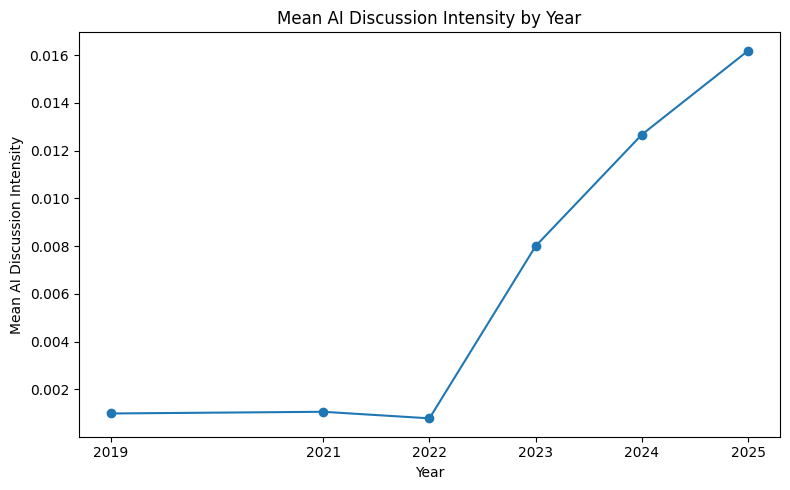

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(ai_by_year["year"], ai_by_year["mean_ai_intensity"], marker="o")

plt.xlabel("Year")
plt.ylabel("Mean AI Discussion Intensity")
plt.title("Mean AI Discussion Intensity by Year")
plt.xticks(ai_by_year["year"])
plt.tight_layout()

plt.savefig("data/processed/mean_ai_intensity_by_year.png", dpi=300)
plt.show()

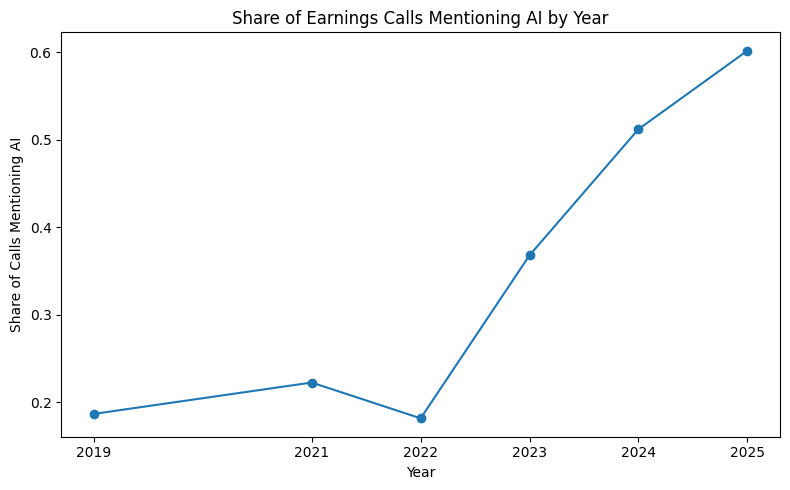

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(ai_by_year["year"], ai_by_year["ai_call_share"], marker="o")

plt.xlabel("Year")
plt.ylabel("Share of Calls Mentioning AI")
plt.title("Share of Earnings Calls Mentioning AI by Year")
plt.xticks(ai_by_year["year"])
plt.tight_layout()

plt.savefig("data/processed/ai_call_share_by_year.png", dpi=300)
plt.show()

In [64]:
dataset_text["hype_period"] = np.select(
    [
        (dataset_text["call_date"] >= pd.Timestamp("2019-01-01")) &
        (dataset_text["call_date"] <= pd.Timestamp("2019-12-31")),

        (dataset_text["call_date"] >= pd.Timestamp("2021-01-01")) &
        (dataset_text["call_date"] < pd.Timestamp("2022-11-30")),

        (dataset_text["call_date"] >= pd.Timestamp("2022-11-30")) &
        (dataset_text["call_date"] <= pd.Timestamp("2023-12-31")),

        dataset_text["call_date"] >= pd.Timestamp("2024-01-01")
    ],
    [
        "2019 Pre-Pandemic Baseline",
        "2021–2022 Pre-ChatGPT Transition",
        "2023 Initial GenAI Surge",
        "2024–2025 AI Adoption Period"
    ],
    default="Unknown"
)

dataset_text["hype_period"].value_counts(dropna=False)

hype_period
2024–2025 AI Adoption Period        1606
2021–2022 Pre-ChatGPT Transition    1596
2023 Initial GenAI Surge             819
2019 Pre-Pandemic Baseline           766
Name: count, dtype: int64

In [65]:
ai_presence_by_period_2019_2025 = dataset_text.groupby("hype_period").agg(
    n_calls=("transcriptid", "count"),
    ai_call_count=("ai_sentence_count", lambda x: (x > 0).sum()),
    ai_call_share=("ai_sentence_count", lambda x: (x > 0).mean()),
    mean_ai_intensity=("ai_intensity", "mean"),
    median_ai_intensity=("ai_intensity", "median"),
    total_ai_sentences=("ai_sentence_count", "sum")
).reset_index()

ai_presence_by_period_2019_2025

,hype_period,n_calls,ai_call_count,ai_call_share,mean_ai_intensity,median_ai_intensity,total_ai_sentences
0,2019 Pre-Pandemic Baseline,766,143,0.186684,0.000992,0.000000,347
1,2021–2022 Pre-ChatGPT Transition,1596,323,0.202381,0.000914,0.000000,732
2,2023 Initial GenAI Surge,819,298,0.363858,0.007881,0.000000,3204
3,2024–2025 AI Adoption Period,1606,894,0.556663,0.014430,0.001984,11305


In [66]:
final_cols = [
    "companyid",
    "companyname",
    "keydevid",
    "transcriptid",
    "headline",
    "call_date",
    "transcriptcollectiontypename",
    "ticker",
    "ticker_startdate",
    "ticker_enddate",
    "primaryflag",
    "transcript_text",
    "total_sentences",
    "ai_sentence_count",
    "ai_intensity",
    "ai_sentences",
    "hype_period"
]

dataset_processed_2019_2025 = dataset_text[final_cols].copy()

In [67]:
ai_presence_by_period_2019_2025.to_csv(
    "data/processed/ai_presence_by_period_2019_2025.csv",
    index=False
)

dataset_processed_2019_2025.to_csv(
    "data/processed/assignment3_processed_ai_discussion_dataset_2019_2025.csv",
    index=False
)

In [68]:
top_ai_calls = dataset_processed_2019_2025.sort_values(
    "ai_intensity",
    ascending=False
)[
    [
        "companyname",
        "call_date",
        "hype_period",
        "total_sentences",
        "ai_sentence_count",
        "ai_intensity",
        "ai_sentences"
    ]
].head(20)

top_ai_calls.to_csv(
    "data/processed/top_ai_intensity_calls_2019_2025.csv",
    index=False
)

top_ai_calls

,companyname,call_date,hype_period,total_sentences,ai_sentence_count,ai_intensity,ai_sentences
4534,"Salesforce, Inc.",2023-05-31,2023 Initial GenAI Surge,552,117,0.211957,"Last quarter, I told you of how our AI team is getting ready to launch Einstein GPT, the world's first generative AI for CRM. ||| At its foundation, Einstein GPT is open and extensible. ||| Customers can connect to multiple large language models, including from partners like OpenAI, Anthropic and others. ||| Users on Salesforce are seeing new AI generative features across all of their most common workflows. ||| For low-code trailblazers, Einstein GPT will provide a tool set to design generat..."
865,Adobe Inc.,2025-09-11,2024–2025 AI Adoption Period,470,96,0.204255,"AI represents a tectonic technology shift and presents the biggest opportunity for Adobe in decades. ||| Our strategy to harness AI is focused on infusing it across our category-leading applications to provide more value and delivering innovative new AI-first products. ||| We're infusing AI across our flagship Creative Cloud Applications, including Photoshop, Illustrator, Premiere Pro and After Effects and delivering new offerings for next-generation creators with Adobe Firefly across web an..."
2707,Cognizant Technology Solutions Corporation,2025-10-29,2024–2025 AI Adoption Period,489,90,0.184049,"Our results reflect the momentum we have built over the past 2.5 years, helping clients embrace AI. ||| Our investments in platforms, intellectual property, partnerships and in upskilling of people are evolving Cognizant into an AI builder, capable of scaling agentic AI across the enterprise. ||| As AI infrastructure expands, our clients increasingly need support from partners who can help them move from experimentation to enterprise-wide adoption with speed, precision and trust. ||| We are ..."
4535,"Salesforce, Inc.",2023-08-30,2023 Initial GenAI Surge,558,100,0.179211,"And last quarter, we told you we're now driving our AI transformation. ||| We're pioneering AI for both our customers and ourselves, leading the industry through this incredible new innovation cycle, and I couldn't be happier with Srini and David and the entire product and technology team for the incredible velocity of AI products that were released to customers this quarter, and the huge impact that they're making in the market and showing how Salesforce is transforming from being not only ..."
886,"Advanced Micro Devices, Inc.",2025-11-04,2024–2025 AI Adoption Period,417,73,0.175060,"Lisa Su will present at the UBS Global Technology and AI Conference on Wednesday, December 3. ||| We delivered an outstanding quarter with record revenue and profitability, reflecting broad-based demand across our data center AI, server and PC businesses. ||| Our record third quarter performance marks a clear step-up in our growth trajectory as the combination of our expanding compute franchise and rapidly scaling data center AI business drives significant revenue and earnings growth. ||| We..."
866,Adobe Inc.,2025-12-10,2024–2025 AI Adoption Period,345,60,0.173913,"In fiscal 2025, Adobe delivered significant AI-influenced and AI-first ending ARR, which accelerated through the year. ||| We are leveraging AI to accelerate innovation to anticipate and serve the needs of large and expanding audiences: Business Professionals and Consumers, Creators and Creative Professionals and Marketing Professionals. ||| Our vision for Business Professionals and Consumers is to deliver AI-driven, quick and easy applications that enable them to be creative and productive,..."
3182,Dell Technologies Inc.,2024-05-30,2024–2025 AI Adoption Period,503,84,0.166998,"We are uniquely positioned to help customers with artificial intelligence, and our strong AI momentum continued in Q1. ||| In ISG, our AI-optimized servers orders increased to $2.6 billion, with shipments up more than 100% sequentially to $1.7 billion. ||| We have now shipped more than $3 billion of AI servers over 

## Prepare Bloomberg Turnover Data Request

In [69]:
import pandas as pd
from pathlib import Path

dataset_processed = pd.read_csv(
    "data/processed/assignment3_processed_ai_discussion_dataset_2019_2025.csv"
)

dataset_processed["call_date"] = pd.to_datetime(dataset_processed["call_date"])

dataset_processed.shape

(4787, 17)

In [70]:
dataset_processed["ticker"].head()

0    DRI
1    1U1
2    DRI
3    1U1
4    ABT
Name: ticker, dtype: object

In [71]:
ticker_list = (
    dataset_processed["ticker"]
    .dropna()
    .astype(str)
    .str.upper()
    .str.strip()
    .unique()
    .tolist()
)

len(ticker_list), ticker_list[:10]

(195, ['DRI', '1U1', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'ARE', 'AFL', 'A'])

In [72]:
ticker_list = (
    dataset_processed["ticker"]
    .dropna()
    .astype(str)
    .str.upper()
    .str.strip()
    .unique()
    .tolist()
)

len(ticker_list), ticker_list[:10]

(195, ['DRI', '1U1', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'ARE', 'AFL', 'A'])

In [73]:
bloomberg_tickers = [t + " US Equity" for t in ticker_list]

ticker_df = pd.DataFrame({"bloomberg_ticker": bloomberg_tickers})

ticker_df.to_csv(
    "data/processed/bloomberg_ticker_list_2019_2025.csv",
    index=False
)

ticker_df.head()

,bloomberg_ticker
0,DRI US Equity
1,1U1 US Equity
2,ABT US Equity
3,ABBV US Equity
4,ACN US Equity


In [74]:
start_date = dataset_processed["call_date"].min() - pd.Timedelta(days=100)
end_date = dataset_processed["call_date"].max() + pd.Timedelta(days=10)

start_date, end_date

(Timestamp('2018-10-06 00:00:00'), Timestamp('2025-12-29 00:00:00'))

In [75]:
date_range_info = pd.DataFrame({
    "item": ["start_date", "end_date"],
    "date": [start_date.date(), end_date.date()]
})

date_range_info.to_csv(
    "data/processed/bloomberg_turnover_date_range.csv",
    index=False
)

date_range_info

,item,date
0,start_date,2018-10-06
1,end_date,2025-12-29


In [77]:
import sys

!{sys.executable} -m pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [78]:
import pandas as pd
from openpyxl import Workbook
from pathlib import Path

ticker_df = pd.read_csv("data/processed/bloomberg_ticker_list_2019_2025.csv")
date_range = pd.read_csv("data/processed/bloomberg_turnover_date_range.csv")

tickers = ticker_df["bloomberg_ticker"].dropna().tolist()

start_date = date_range.loc[date_range["item"] == "start_date", "date"].iloc[0]
end_date = date_range.loc[date_range["item"] == "end_date", "date"].iloc[0]

output_path = "data/raw/bloomberg_turnover_template_2019_2025.xlsx"

wb = Workbook()

# Remove default sheet
ws_default = wb.active
wb.remove(ws_default)

def add_bdh_sheet(wb, sheet_name, field_name):
    ws = wb.create_sheet(sheet_name)
    
    for i, ticker in enumerate(tickers):
        start_col = i * 3 + 1
        label_col = start_col
        value_col = start_col + 1
        
        # Header inputs
        ws.cell(row=1, column=label_col, value="ticker")
        ws.cell(row=1, column=value_col, value=ticker)
        
        ws.cell(row=2, column=label_col, value="start_date")
        ws.cell(row=2, column=value_col, value=start_date)
        
        ws.cell(row=3, column=label_col, value="end_date")
        ws.cell(row=3, column=value_col, value=end_date)
        
        # Bloomberg formula
        # Example: =BDH($B$1,"PX_VOLUME",$B$2,$B$3)
        col_letter = ws.cell(row=1, column=value_col).column_letter
        formula = f'=BDH(${col_letter}$1,"{field_name}",${col_letter}$2,${col_letter}$3)'
        ws.cell(row=5, column=label_col, value=formula)

add_bdh_sheet(wb, "PX_VOLUME", "PX_VOLUME")
add_bdh_sheet(wb, "EQY_SH_OUT", "EQY_SH_OUT")

wb.save(output_path)

output_path

'data/raw/bloomberg_turnover_template_2019_2025.xlsx'

In [79]:
from pathlib import Path

desktop = Path.home() / "Desktop"
list(desktop.glob("*.xlsx"))

[PosixPath('/Users/zhongnianzhanlang/Desktop/~$bloomberg_turnover_template_2019_2025(1).xlsx'),
 PosixPath('/Users/zhongnianzhanlang/Desktop/bloomberg_turnover_template_2019_2025(1).xlsx')]

In [80]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Desktop" / "bloomberg_turnover_template_2019_2025(1).xlsx"

xls = pd.ExcelFile(file_path)

xls.sheet_names

['PX_VOLUME', 'EQY_SH_OUT']

In [81]:
px_volume_raw = pd.read_excel(file_path, sheet_name="PX_VOLUME", header=None)
shares_raw = pd.read_excel(file_path, sheet_name="EQY_SH_OUT", header=None)

print(px_volume_raw.shape)
print(shares_raw.shape)

display(px_volume_raw.head(10))
display(shares_raw.head(10))

(1821, 584)
(1821, 584)


,0,1,2,3,4,5,6,7,8,9,...,574,575,576,577,578,579,580,581,582,583
0,ticker,DRI US Equity,NaN,ticker,1U1 US Equity,NaN,ticker,ABT US Equity,NaN,ticker,...,ABNB US Equity,NaN,ticker,AXON US Equity,NaN,ticker,CARR US Equity,NaN,ticker,DASH US Equity
1,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,...,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06
2,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,...,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,1105537,NaN,NaN,NaN,NaN,NaN,5520460,NaN,NaN,...,NaN,NaN,NaN,664016,NaN,NaN,100,NaN,NaN,NaN
5,2018-10-09 00:00:00,1272041,NaN,NaN,NaN,NaN,2018-10-09 00:00:00,4812290,NaN,2018-10-09 00:00:00,...,70447537,NaN,2018-10-09 00:00:00,499786,NaN,2020-03-20 00:00:00,2348,NaN,2020-12-09 00:00:00,25373661
6,2018-10-10 00:00:00,1220378,NaN,NaN,NaN,NaN,2018-10-10 00:00:00,10559290,NaN,2018-10-10 00:00:00,...,26980830,NaN,2018-10-10 00:00:00,1078593,NaN,2020-03-23 00:00:00,18710,NaN,2020-12-10 00:00:00,9307612
7,2018-10-11 00:00:00,2045715,NaN,NaN,NaN,NaN,2018-10-11 00:00:00,11932283,NaN,2018-10-11 00:00:00,...,16966089,NaN,2018-10-11 00:00:00,820736,NaN,2020-03-24 00:00:00,96074,NaN,2020-12-11 00:00:00,4760590
8,2018-10-12 00:00:00,1671027,NaN,NaN,NaN,NaN,2018-10-12 00:00:00,10431269,NaN,2018-10-12 00:00:00,...,10914432,NaN,2018-10-12 00:00:00,701824,NaN,2020-03-25 00:00:00,19242,NaN,2020-12-14 00:00:00,7859600
9,2018-10-15 00:00:00,922093,NaN,NaN,NaN,NaN,2018-10-15 00:00:00,6674712,NaN,2018-10-15 00:00:00,...,20409551,NaN,2018-10-15 00:00:00,789110,NaN,2020-03-26 00:00:00,76379,NaN,2020-12-15 00:00:00,5017013


,0,1,2,3,4,5,6,7,8,9,...,574,575,576,577,578,579,580,581,582,583
0,ticker,DRI US Equity,NaN,ticker,1U1 US Equity,NaN,ticker,ABT US Equity,NaN,ticker,...,ABNB US Equity,NaN,ticker,AXON US Equity,NaN,ticker,CARR US Equity,NaN,ticker,DASH US Equity
1,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,...,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06,NaN,start_date,2018-10-06
2,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,...,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29,NaN,end_date,2025-12-29
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,124.11046,NaN,NaN,NaN,NaN,NaN,1754.31928,NaN,NaN,...,98.911,NaN,NaN,58.3197,NaN,NaN,NaN,NaN,NaN,286.34307
5,2018-10-09 00:00:00,124.11046,NaN,NaN,NaN,NaN,2018-10-09 00:00:00,1754.31928,NaN,2018-10-09 00:00:00,...,98.911,NaN,2018-10-09 00:00:00,58.3197,NaN,2020-03-20 00:00:00,NaN,NaN,2020-12-09 00:00:00,286.34307
6,2018-10-10 00:00:00,124.11046,NaN,NaN,NaN,NaN,2018-10-10 00:00:00,1754.31928,NaN,2018-10-10 00:00:00,...,103.68255,NaN,2018-10-10 00:00:00,58.3197,NaN,2020-03-23 00:00:00,NaN,NaN,2020-12-10 00:00:00,286.34307
7,2018-10-11 00:00:00,124.11046,NaN,NaN,NaN,NaN,2018-10-11 00:00:00,1754.31928,NaN,2018-10-11 00:00:00,...,103.68255,NaN,2018-10-11 00:00:00,58.3197,NaN,2020-03-24 00:00:00,NaN,NaN,2020-12-11 00:00:00,286.34307
8,2018-10-12 00:00:00,124.11046,NaN,NaN,NaN,NaN,2018-10-12 00:00:00,1754.31928,NaN,2018-10-12 00:00:00,...,103.68255,NaN,2018-10-12 00:00:00,58.3197,NaN,2020-03-25 00:00:00,NaN,NaN,2020-12-14 00:00:00,286.34307
9,2018-10-15 00:00:00,124.11046,NaN,NaN,NaN,NaN,2018-10-15 00:00:00,1754.31928,NaN,2018-10-15 00:00:00,...,103.68255,NaN,2018-10-15 00:00:00,58.3197,NaN,2020-03-26 00:00:00,NaN,NaN,2020-12-15 00:00:00,286.34307


In [82]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. 文件路径
file_path = Path.home() / "Desktop" / "bloomberg_turnover_template_2019_2025(1).xlsx"

# 2. 读取两个 sheet
px_raw = pd.read_excel(file_path, sheet_name="PX_VOLUME", header=None)
sh_raw = pd.read_excel(file_path, sheet_name="EQY_SH_OUT", header=None)

def bloomberg_wide_to_long(raw_df, value_name):
    """
    Convert Bloomberg Excel output from repeated 3-column blocks:
    [date, value, blank], [date, value, blank], ...
    into long format.
    """
    all_parts = []
    
    # 每 3 列是一家公司
    for start_col in range(0, raw_df.shape[1], 3):
        date_col = start_col
        value_col = start_col + 1
        
        # 防止最后列不完整
        if value_col >= raw_df.shape[1]:
            continue
        
        # ticker 在第 0 行、第 value_col 列
        ticker = raw_df.iloc[0, value_col]
        
        # 跳过空 ticker
        if pd.isna(ticker):
            continue
        
        # 数据从第 4 行开始；第 4 行可能 date 缺失，所以后面会清理
        temp = raw_df.iloc[4:, [date_col, value_col]].copy()
        temp.columns = ["trading_date", value_name]
        temp["ticker"] = ticker
        
        all_parts.append(temp)
    
    long_df = pd.concat(all_parts, ignore_index=True)
    
    # 日期转成 datetime，错误日期变成 NaT
    long_df["trading_date"] = pd.to_datetime(long_df["trading_date"], errors="coerce")
    
    # 数值转成 numeric
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    
    # 删除没有日期的行
    long_df = long_df.dropna(subset=["trading_date"])
    
    # 删除没有数值的行
    long_df = long_df.dropna(subset=[value_name])
    
    # 只保留研究期
    long_df = long_df[
        (long_df["trading_date"] >= "2019-01-01") &
        (long_df["trading_date"] <= "2025-12-31")
    ]
    
    # 整理列顺序
    long_df = long_df[["ticker", "trading_date", value_name]]
    
    return long_df


# 3. 转成长表
px_long = bloomberg_wide_to_long(px_raw, "PX_VOLUME")
sh_long = bloomberg_wide_to_long(sh_raw, "EQY_SH_OUT")

print("PX_VOLUME long shape:", px_long.shape)
print("EQY_SH_OUT long shape:", sh_long.shape)

display(px_long.head())
display(sh_long.head())

PX_VOLUME long shape: (329841, 3)
EQY_SH_OUT long shape: (329820, 3)


,ticker,trading_date,PX_VOLUME
58,DRI US Equity,2019-01-02,1563635.0
59,DRI US Equity,2019-01-03,1857837.0
60,DRI US Equity,2019-01-04,2070148.0
61,DRI US Equity,2019-01-07,1889290.0
62,DRI US Equity,2019-01-08,1676743.0


,ticker,trading_date,EQY_SH_OUT
58,DRI US Equity,2019-01-02,123.50908
59,DRI US Equity,2019-01-03,123.50908
60,DRI US Equity,2019-01-04,123.50908
61,DRI US Equity,2019-01-07,123.50908
62,DRI US Equity,2019-01-08,123.50908


In [83]:
# 4. 合并 volume 和 shares outstanding
turnover_daily = pd.merge(
    px_long,
    sh_long,
    on=["ticker", "trading_date"],
    how="outer"
)

# 5. 计算 turnover
# Bloomberg 的 EQY_SH_OUT 通常是 million shares，所以要乘以 1,000,000
turnover_daily["turnover"] = (
    turnover_daily["PX_VOLUME"] / 
    (turnover_daily["EQY_SH_OUT"] * 1_000_000)
)

# 6. 清理异常值
turnover_daily = turnover_daily.sort_values(["ticker", "trading_date"]).reset_index(drop=True)

display(turnover_daily.head(20))

print("Final shape:", turnover_daily.shape)
print("Number of tickers:", turnover_daily["ticker"].nunique())
print("Date range:", turnover_daily["trading_date"].min(), "to", turnover_daily["trading_date"].max())
print("Missing PX_VOLUME:", turnover_daily["PX_VOLUME"].isna().sum())
print("Missing EQY_SH_OUT:", turnover_daily["EQY_SH_OUT"].isna().sum())
print("Missing turnover:", turnover_daily["turnover"].isna().sum())

,ticker,trading_date,PX_VOLUME,EQY_SH_OUT,turnover
0,A US Equity,2019-01-02,2113304.0,318.53305,0.006634
1,A US Equity,2019-01-03,5383926.0,318.53305,0.016902
2,A US Equity,2019-01-04,3123654.0,318.53305,0.009806
3,A US Equity,2019-01-07,3235055.0,318.53305,0.010156
4,A US Equity,2019-01-08,1578055.0,318.53305,0.004954
5,A US Equity,2019-01-09,2442291.0,318.53305,0.007667
6,A US Equity,2019-01-10,1080882.0,318.53305,0.003393
7,A US Equity,2019-01-11,1210791.0,318.53305,0.003801
8,A US Equity,2019-01-14,2182673.0,318.53305,0.006852
9,A US Equity,2019-01-15,1793061.0,318.53305,0.005629


Final shape: (329842, 5)
Number of tickers: 189
Date range: 2019-01-02 00:00:00 to 2025-12-29 00:00:00
Missing PX_VOLUME: 1
Missing EQY_SH_OUT: 22
Missing turnover: 23


In [84]:
ticker_check = (
    turnover_daily
    .groupby("ticker")
    .agg(
        n_days=("trading_date", "nunique"),
        n_volume=("PX_VOLUME", "count"),
        n_shares=("EQY_SH_OUT", "count"),
        n_turnover=("turnover", "count"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max")
    )
    .reset_index()
    .sort_values("n_turnover")
)

display(ticker_check.head(20))

,ticker,n_days,n_volume,n_shares,n_turnover,first_date,last_date
157,EXE US Equity,1226,1226,1226,1226,2021-02-11,2025-12-29
3,ABNB US Equity,1268,1268,1268,1268,2020-12-10,2025-12-29
116,DASH US Equity,1269,1269,1269,1269,2020-12-09,2025-12-29
69,CARR US Equity,1452,1452,1442,1442,2020-03-20,2025-12-29
118,DDOG US Equity,1578,1578,1578,1578,2019-09-19,2025-12-29
104,CRWD US Equity,1647,1647,1647,1647,2019-06-12,2025-12-29
25,AMCR US Equity,1647,1647,1647,1647,2019-06-12,2025-12-29
110,CTVA US Equity,1658,1658,1654,1654,2019-05-28,2025-12-29
130,DOW US Equity,1704,1704,1704,1704,2019-03-21,2025-12-29
172,FOXA US Equity,1710,1710,1706,1706,2019-03-13,2025-12-29


In [85]:
output_path = Path.home() / "Desktop" / "turnover_daily_clean_2019_2025.csv"

turnover_daily.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/zhongnianzhanlang/Desktop/turnover_daily_clean_2019_2025.csv


In [86]:
print("Final shape:", turnover_daily.shape)
print("Number of tickers:", turnover_daily["ticker"].nunique())
print("Missing PX_VOLUME:", turnover_daily["PX_VOLUME"].isna().sum())
print("Missing EQY_SH_OUT:", turnover_daily["EQY_SH_OUT"].isna().sum())
print("Missing turnover:", turnover_daily["turnover"].isna().sum())

display(ticker_check.head(20))

Final shape: (329842, 5)
Number of tickers: 189
Missing PX_VOLUME: 1
Missing EQY_SH_OUT: 22
Missing turnover: 23


,ticker,n_days,n_volume,n_shares,n_turnover,first_date,last_date
157,EXE US Equity,1226,1226,1226,1226,2021-02-11,2025-12-29
3,ABNB US Equity,1268,1268,1268,1268,2020-12-10,2025-12-29
116,DASH US Equity,1269,1269,1269,1269,2020-12-09,2025-12-29
69,CARR US Equity,1452,1452,1442,1442,2020-03-20,2025-12-29
118,DDOG US Equity,1578,1578,1578,1578,2019-09-19,2025-12-29
104,CRWD US Equity,1647,1647,1647,1647,2019-06-12,2025-12-29
25,AMCR US Equity,1647,1647,1647,1647,2019-06-12,2025-12-29
110,CTVA US Equity,1658,1658,1654,1654,2019-05-28,2025-12-29
130,DOW US Equity,1704,1704,1704,1704,2019-03-21,2025-12-29
172,FOXA US Equity,1710,1710,1706,1706,2019-03-13,2025-12-29


In [87]:
turnover_daily_clean = turnover_daily.dropna(subset=["turnover"]).copy()

print(turnover_daily_clean.shape)
print(turnover_daily_clean["ticker"].nunique())

(329819, 5)
189


In [88]:
turnover_daily_clean["turnover_pct"] = turnover_daily_clean["turnover"] * 100

display(turnover_daily_clean.head())

,ticker,trading_date,PX_VOLUME,EQY_SH_OUT,turnover,turnover_pct
0,A US Equity,2019-01-02,2113304.0,318.53305,0.006634,0.663449
1,A US Equity,2019-01-03,5383926.0,318.53305,0.016902,1.690225
2,A US Equity,2019-01-04,3123654.0,318.53305,0.009806,0.980637
3,A US Equity,2019-01-07,3235055.0,318.53305,0.010156,1.015610
4,A US Equity,2019-01-08,1578055.0,318.53305,0.004954,0.495413


In [89]:
turnover_daily_clean["turnover_pct"].describe()

count    329819.000000
mean          0.907018
std           1.338679
min           0.000397
25%           0.448310
50%           0.641847
75%           0.989114
max         165.546283
Name: turnover_pct, dtype: float64

In [90]:
turnover_daily_clean.sort_values("turnover", ascending=False).head(20)

,ticker,trading_date,PX_VOLUME,EQY_SH_OUT,turnover,turnover_pct
195137,CVNA US Equity,2023-06-08,878905015.0,530.91196,1.655463,165.546283
195050,CVNA US Equity,2023-02-02,741463325.0,529.73872,1.399677,139.967742
195164,CVNA US Equity,2023-07-19,599745010.0,532.71927,1.125818,112.581813
195012,CVNA US Equity,2022-12-07,592416985.0,529.73872,1.118319,111.831921
181926,CRWD US Equity,2019-06-12,19449162.0,18.00000,1.080509,108.050900
195047,CVNA US Equity,2023-01-30,541955835.0,529.73872,1.023063,102.306253
195138,CVNA US Equity,2023-06-09,500953560.0,530.91196,0.943572,94.357181
205838,DDOG US Equity,2019-09-19,22073186.0,24.00000,0.919716,91.971608
195036,CVNA US Equity,2023-01-12,437042635.0,529.73872,0.825015,82.501546
195049,CVNA US Equity,2023-02-01,432127145.0,529.73872,0.815736,81.573638


In [91]:
from pathlib import Path

output_path = Path.home() / "Desktop" / "turnover_daily_clean_2019_2025.csv"

turnover_daily_clean.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/zhongnianzhanlang/Desktop/turnover_daily_clean_2019_2025.csv


In [92]:
import pandas as pd
from pathlib import Path

# 改成你的 full text 文件实际路径
input_path = Path.home() / "Desktop" / "earnings_call_transcripts_2019_2025_with_text.csv"

df = pd.read_csv(input_path)

keep_cols = [
    "ticker",
    "companyname",
    "transcriptid",
    "keydevid",
    "headline",
    "mostimportantdateutc",
    "total_sentences",
    "ai_sentence_count",
    "ai_intensity"
]

keep_cols_existing = [col for col in keep_cols if col in df.columns]

earnings_call_ai_dataset = df[keep_cols_existing].copy()

if "mostimportantdateutc" in earnings_call_ai_dataset.columns:
    earnings_call_ai_dataset = earnings_call_ai_dataset.rename(
        columns={"mostimportantdateutc": "call_date"}
    )

output_path = Path.home() / "Desktop" / "earnings_call_ai_dataset.csv"

earnings_call_ai_dataset.to_csv(output_path, index=False)

print("Saved to:", output_path)
print("Shape:", earnings_call_ai_dataset.shape)
print("Columns:", earnings_call_ai_dataset.columns.tolist())

Saved to: /Users/zhongnianzhanlang/Desktop/earnings_call_ai_dataset.csv
Shape: (4787, 5)
Columns: ['ticker', 'companyname', 'transcriptid', 'keydevid', 'headline']


In [93]:
sample_path = Path.home() / "Desktop" / "earnings_call_transcripts_2019_2025_sample_1000.csv"

df.head(1000).to_csv(sample_path, index=False)

print("Saved sample to:", sample_path)

Saved sample to: /Users/zhongnianzhanlang/Desktop/earnings_call_transcripts_2019_2025_sample_1000.csv
